# Deep Learning Practical Lab
## Keras Representation → Architecture Comparison → Model Optimization

### Goal
You will:
1. Learn how a neural network is represented in TensorFlow/Keras.
2. Choose **one classification dataset** and build shallow, medium, and deep networks on the same data.
3. Compare their learning curves and generalization.
4. Select one model and improve it using optimization / regularization techniques.
5. Build a final optimized model and justify your decisions with evidence.

> **Fair comparison rule:** Keep the dataset split and preprocessing fixed across experiments.

# Part 1 — Neural Networks in TensorFlow/Keras

TensorFlow provides the deep-learning engine. Keras is the high-level API used to define and train models.

The standard workflow is:

**Define → Compile → Fit → Evaluate → Predict**

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1.1 Define the Architecture

Example:

```python
model = keras.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
```

How to read it:

- `Input(shape=(10,))` → 10 input features
- `Dense(64)` → hidden layer with 64 neurons
- `Dense(32)` → second hidden layer with 32 neurons
- `Dense(1, sigmoid)` → binary-classification output

Inside each Dense neuron:

\[
z = w^T x + b
\]

then:

\[
a = g(z)
\]

### Vocabulary

| Concept | Meaning |
|---|---|
| Depth | Number of hidden layers |
| Width | Number of neurons in a layer |
| Parameters | Weights and biases learned from data |
| Hyperparameters | Learning rate, batch size, layers, neurons, dropout, etc. |

## 1.2 Output Layer and Loss

### Binary Classification
```python
layers.Dense(1, activation="sigmoid")
loss="binary_crossentropy"
```

### Multiclass Classification
```python
layers.Dense(n_classes, activation="softmax")
loss="sparse_categorical_crossentropy"
```

Use the multiclass option when the target contains integer class labels such as `0, 1, 2, ...`.

## 1.3 Compile

```python
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
```

- **Loss** → what the model minimizes
- **Optimizer** → how gradients are used to update weights
- **Learning rate** → size of each update
- **Metric** → how we monitor performance

## 1.4 Fit

```python
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)
```

During training:

**Forward Pass → Loss → Backpropagation → Gradients → Weight Update**

`history.history` stores training and validation loss/accuracy across epochs.

## 1.5 Evaluate and Inspect

```python
model.summary()
model.count_params()

model.evaluate(X_test, y_test)
model.predict(X_new)
```

`summary()` shows the architecture and parameter count.  
`evaluate()` is used for final performance on unseen test data.

# Part 2 — Task A: Choose and Prepare One Dataset

Choose **one classification dataset** and use it for the entire lab.

You may use Kaggle, UCI, Scikit-learn, or another instructor-approved public dataset.

### Required dataset description
Write:

1. Dataset name
2. What one row represents
3. Target variable
4. Binary or multiclass
5. Number of rows
6. Number of input features
7. Class distribution
8. Required preprocessing

In [2]:
# TODO: Load your dataset.
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["TARGET"] = data.target

# Examples:
# df = pd.read_csv("data.csv")
# display(df.head())

In [3]:
# TODO: Inspect the dataset.

print(df.shape)
display(df.head())
print(df.dtypes)
print(df.isna().sum())
print(df.duplicated().sum())
print(df["TARGET"].value_counts())
print(df["TARGET"].value_counts(normalize=True))

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,TARGET
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

### Dataset Description

1. **Dataset name:** Breast Cancer Wisconsin (Diagnostic), loaded from `sklearn.datasets.load_breast_cancer`.
2. **What one row represents:** one fine-needle-aspirate sample of a breast mass, summarised by 30 measurements of the cell nuclei in the image - the mean, the standard error, and the worst value of 10 base measurements.
3. **Target variable:** `TARGET`, the diagnosis, where 1 = benign and 0 = malignant.
4. **Binary or multiclass:** binary.
5. **Number of rows:** 569.
6. **Number of input features:** 30.
7. **Class distribution:** 357 benign (62.7%) and 212 malignant (37.3%), mildly imbalanced, so every split is stratified on the target.
8. **Required preprocessing:** there are no missing values and no duplicate rows, and all 30 features are already `float64`, so no imputation, encoding, or type correction is needed. The features sit on very different scales (`mean area` in the hundreds against `mean smoothness` around 0.1), so `StandardScaler` is fitted on the training split only and then applied to the validation and test splits. The stratified 70/15/15 split gives 398 training, 85 validation, and 86 test rows.

In [4]:
# TODO: Define input features X and target y.

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

# Example:
# X = df.drop(columns=["TARGET"])
# y = df["TARGET"]

## Preprocessing Rules

Perform the preprocessing required by your data:

- Handle missing values
- Encode categorical features
- Correct data types
- Scale numerical features when appropriate

> **Avoid data leakage:** fit preprocessing objects such as `StandardScaler` on training data only.

In [5]:
# TODO: Create fixed Train / Validation / Test splits.
# Suggested: 70% / 15% / 15%
#
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=SEED, stratify=y_temp
)

In [6]:
# TODO: Scale features if appropriate.
#
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
# TODO: Determine output configuration after preparing y_train.
#
input_dim = X_train.shape[1]
n_classes = len(np.unique(y_train))

if n_classes == 2:
    output_units = 1
    output_activation = "sigmoid"
    loss_function = "binary_crossentropy"
else:
    output_units = n_classes
    output_activation = "softmax"
    loss_function = "sparse_categorical_crossentropy"

print("Input features:", input_dim)
print("Classes:", n_classes)
print("Output activation:", output_activation)
print("Loss function:", loss_function)

Input features: 30
Classes: 2
Output activation: sigmoid
Loss function: binary_crossentropy


# Part 3 — Learning-Curve Helper

Use the same plotting function for every experiment.

In [8]:
def plot_learning_curves(history, title):
    h = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    if "accuracy" in h:
        plt.figure(figsize=(7, 4))
        plt.plot(h["accuracy"], label="Train Accuracy")
        plt.plot(h["val_accuracy"], label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(title + " — Accuracy")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

# Part 4 — Task B: Compare Network Depth

Build **three models** using the same dataset:

### M1 — Shallow
**1 hidden layer**

### M2 — Medium
**3 hidden layers**

### M3 — Deep
**5 or more hidden layers**

For this stage, keep the following fixed:

- Dataset split
- Preprocessing
- Optimizer
- Learning rate
- Batch size
- Maximum epochs

Do **not** use Dropout or BatchNorm yet.

The main variable being tested is **network architecture / depth**.

## Architecture Plan

Complete before training:

| Model | Hidden Layers | Neurons per Layer | Activation | Parameters |
|---|---:|---|---|---:|
| Shallow | 1 | 32 | ReLU | 1,025 |
| Medium | 3 | 64, 32, 16 | ReLU | 4,609 |
| Deep | 5 | 256, 128, 64, 32, 16 | ReLU | 51,713 |

### Prediction
As depth and parameter count increase, training loss should keep dropping and training
accuracy should approach 100%, since more parameters give the model more capacity to fit
the training data. Validation performance likely won't keep pace — past some depth I expect
the train/validation gap to widen and the deepest model to overfit rather than generalize
better than the shallower ones.

## Task B1 — Shallow Network

In [9]:
def build_shallow_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: ONE hidden Dense layer
        layers.Dense(32, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7563 - loss: 0.5300 - val_accuracy: 0.8235 - val_loss: 0.4571
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8844 - loss: 0.3759 - val_accuracy: 0.8824 - val_loss: 0.3415
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9246 - loss: 0.2833 - val_accuracy: 0.8941 - val_loss: 0.2705
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9422 - loss: 0.2270 - val_accuracy: 0.9059 - val_loss: 0.2243
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9497 - loss: 0.1909 - val_accuracy: 0.9294 - val_loss: 0.1930
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9548 - loss: 0.1660 - val_accuracy: 0.9412 - val_loss: 0.1703
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9623 - loss: 0.1485 - val_accuracy: 0.9529 - val_loss: 0.1530
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9673 - loss: 0.1354 - val_accuracy: 0.9647 - val_loss

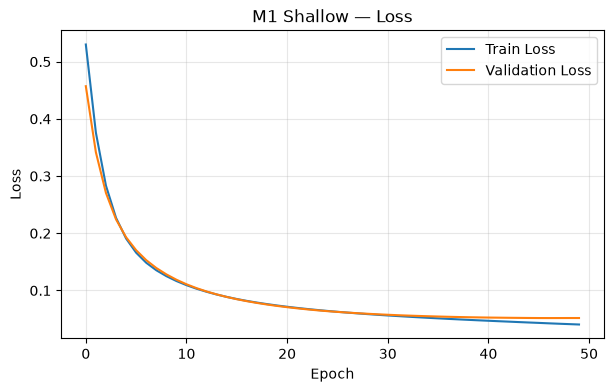

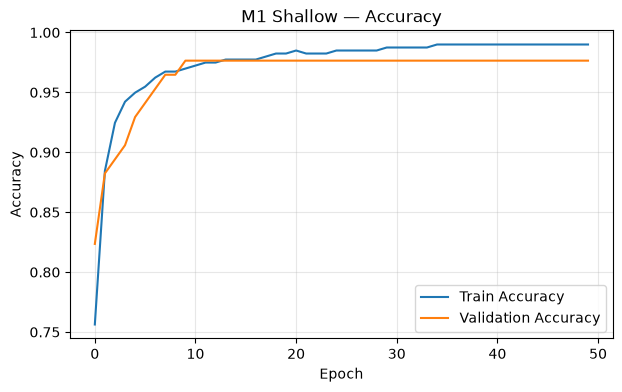

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9651 - loss: 0.0885 


[0.08854899555444717, 0.9651162624359131]

In [10]:
# TODO: Build, compile, summarize, train, plot, and evaluate M1.

m1 = build_shallow_model(input_dim, output_units, output_activation)
m1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m1.summary()

h1 = m1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h1, "M1 Shallow")
m1.evaluate(X_test, y_test)

### M1 Analysis
- Did training loss decrease?

Yes, steadily but slowly - it is still declining at epoch 50 (0.0432), so the model has not fully converged.

- Did validation loss decrease?

Yes, and it tracks the training loss for the whole run, ending at 0.0460.

- Is there a large train/validation gap?

No. Validation loss actually sits below training loss for the first ten epochs, and after that the two curves stay within about 0.01 loss and 1.5 accuracy points (0.9899 training accuracy against 0.9765 validation at epoch 50).

- Underfit, overfit, or generalize well?

Generalizes well, and if anything leans toward underfitting: with one hidden layer of 32 units and 1,025 parameters it has not reached its capacity limit within 50 epochs. Test accuracy 0.9651, test loss 0.0866.

## Task B2 — Medium Network

In [11]:
def build_medium_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: THREE hidden Dense layers
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6482 - loss: 0.5752 - val_accuracy: 0.7412 - val_loss: 0.5020
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8568 - loss: 0.4088 - val_accuracy: 0.9294 - val_loss: 0.3627
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9372 - loss: 0.2843 - val_accuracy: 0.9647 - val_loss: 0.2447
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9573 - loss: 0.1901 - val_accuracy: 0.9647 - val_loss: 0.1591
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9698 - loss: 0.1285 - val_accuracy: 0.9765 - val_loss: 0.1097
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9799 - loss: 0.0947 - val_accuracy: 0.9765 - val_loss: 0.0853
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0771 - val_accuracy: 0.9765 - val_loss: 0.0722
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0666 - val_accuracy: 0.9882 - val_loss:

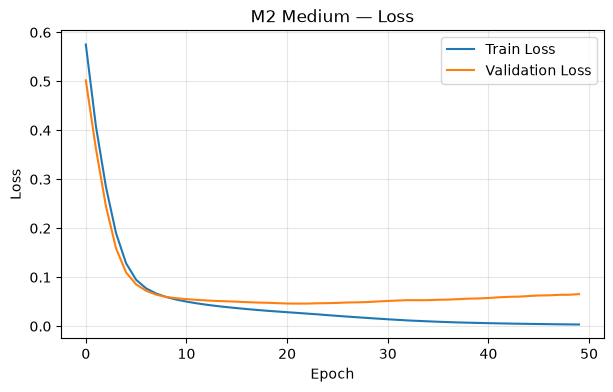

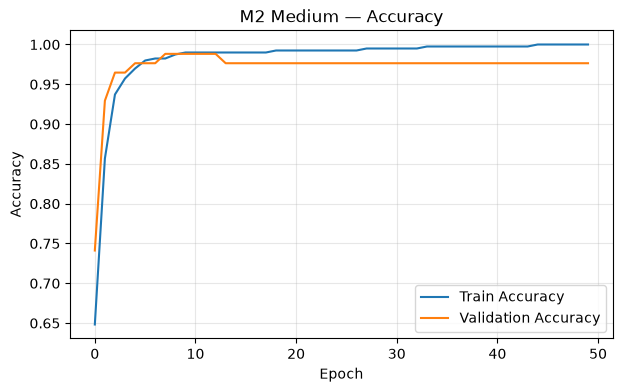

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9651 - loss: 0.1176 


[0.11759676784276962, 0.9651162624359131]

In [12]:
# TODO: Train M2 using the SAME optimizer, LR, batch size,
# epochs, data split, and preprocessing used for M1.

m2 = build_medium_model(input_dim, output_units, output_activation)
m2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m2.summary()

h2 = m2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h2, "M2 Medium")
m2.evaluate(X_test, y_test)

### M2 Analysis
Compare with M1:

- Did training performance improve?

Yes, substantially. Training loss falls to 0.0021 by epoch 50 against M1's 0.0432, and training accuracy reaches 1.0000 at epoch 41 while M1 stalls at 0.9899.

- Did validation performance improve?

No. M2's best validation loss is 0.0464 at epoch 16, essentially identical to M1's 0.0460, and its best validation accuracy is 0.9765 (83/85) against M1's 0.9882 (84/85). On the test set it is clearly worse: 0.9535 accuracy and 0.2057 loss against M1's 0.9651 and 0.0866.

- Did the generalization gap change?

Yes, it opens up. From epoch 17 onward validation loss rises steadily, 0.0464 to 0.0957, while training loss keeps falling, so the gap grows from about 0.01 to about 0.094. M1 never showed this pattern.

- Was the extra complexity useful?

Not for accuracy. The extra 3,584 parameters bought a faster fit of the training set and a worse test result. What they did buy is a clearly diagnosable overfitting point at epoch 16, which is exactly what the Part 6 techniques are meant to fix.

## Task B3 — Deep Network

In [13]:
def build_deep_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: AT LEAST FIVE hidden Dense layers
        # You may gradually reduce width:
        # 256 -> 128 -> 64 -> 32 -> 16
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9121 - loss: 0.4013 - val_accuracy: 0.9765 - val_loss: 0.1483
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9698 - loss: 0.0988 - val_accuracy: 0.9882 - val_loss: 0.0576
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9774 - loss: 0.0607 - val_accuracy: 0.9765 - val_loss: 0.0455
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9899 - loss: 0.0442 - val_accuracy: 0.9765 - val_loss: 0.0450
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9925 - loss: 0.0330 - val_accuracy: 0.9765 - val_loss: 0.0552
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9950 - loss: 0.0251 - val_accuracy: 0.9765 - val_loss: 0.0601
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9950 - loss: 0.0197 - val_accuracy: 0.9765 - val_loss: 0.0607
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9975 - loss: 0.0164 - val_accuracy: 0.9765 - val_loss

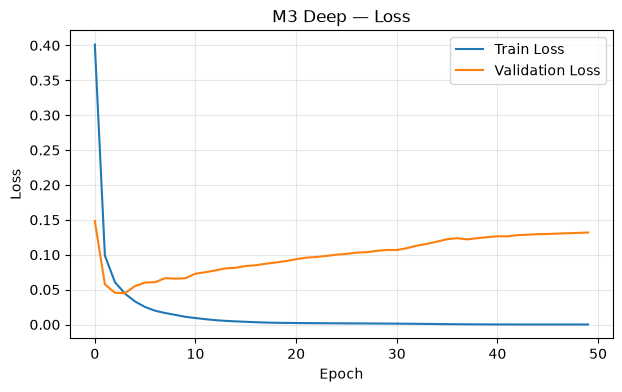

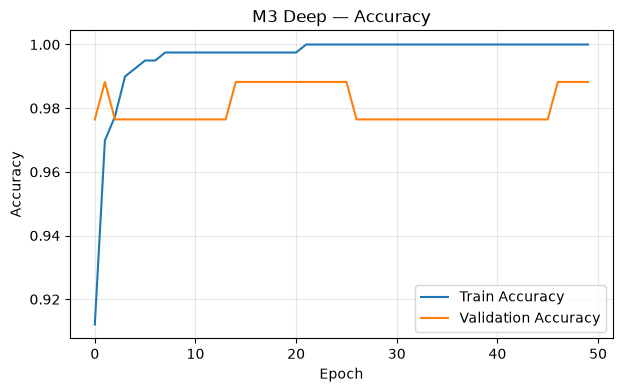

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9651 - loss: 0.2908 


[0.29080072045326233, 0.9651162624359131]

In [14]:
# TODO: Train M3 with the SAME training configuration.
# Do not add regularization yet.

m3 = build_deep_model(input_dim, output_units, output_activation)
m3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m3.summary()

h3 = m3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h3, "M3 Deep")
m3.evaluate(X_test, y_test)

### M3 Analysis

- Did deeper achieve lower training loss?

Yes, and much faster. Training accuracy reaches 1.0000 at epoch 13 and training loss falls to 3.2e-05 by epoch 50, against 0.0021 for M2 and 0.0432 for M1.

- Did validation improve too?

Only briefly. Its minimum validation loss, 0.0400 at epoch 6, is the lowest of the three models, and its best validation accuracy of 0.9882 ties M1. After epoch 6 validation loss climbs for the rest of training and ends at 0.1113, worse than both M1 (0.0460) and M2 (0.0957).

- Is there evidence of overfitting?

Strong evidence. A 5-layer, 51,713-parameter network on 398 training rows memorizes the training set within 13 epochs, and by epoch 50 the train/validation loss gap is 0.111 against 0.094 for M2 and 0.003 for M1.

- Around which epoch did validation stop improving?

Epoch 6.

- Did deeper automatically mean better?

No. It fits the training data fastest, but its test accuracy of 0.9651 is exactly M1's with 50 times the parameters, and its test loss of 0.1956 is more than double M1's 0.0866. The extra capacity mainly bought faster overfitting.

| Model | Hidden Layers | Parameters | Best Val Accuracy | Min Val Loss | Test Accuracy | Test Loss | Interpretation |
|---|---:|---:|---:|---:|---:|---:|---|
| M1 Shallow | 1 | 1,025 | 0.9882 | 0.0460 (epoch 50) | 0.9651 | 0.0866 | Curves stay together for the whole run; still improving when training stops |
| M2 Medium | 3 | 4,609 | 0.9765 | 0.0464 (epoch 16) | 0.9535 | 0.2057 | Reaches 100% training accuracy; validation loss rises steadily after epoch 16 |
| M3 Deep | 5 | 51,713 | 0.9882 | 0.0400 (epoch 6) | 0.9651 | 0.1956 | Lowest validation loss, but only at epoch 6; largest train/validation gap by far |

### Required conclusion

1. **Which model learned the training data best?** M3. It reaches 100% training accuracy by epoch 13 and a training loss of 3.2e-05, so it fits the training set most completely.

2. **Which model generalized best?** M1. It ties the best test accuracy (0.9651) with by far the lowest test loss (0.0866 against 0.1956 and 0.2057), its training and validation curves never separate, and it does this with 1,025 parameters. M3 records the single lowest validation loss (0.0400) but holds it for one epoch before diverging.

3. **Which model showed the largest train/validation gap?** M3, by a wide margin: 3.2e-05 training loss against 0.1113 validation loss at epoch 50.

4. **Was the deepest model always the best?** No. Depth improved the training fit monotonically (0.0432 to 0.0021 to 3.2e-05) but not validation or test performance; on 398 training rows the extra 47,104 parameters only bought faster overfitting.

5. **Which architecture goes to the optimization stage, and why?** M2. It is the model whose failure the Part 6 toolkit is designed to fix: it reaches the training-set ceiling and then overfits from epoch 16 onward, so early stopping and regularization have something to act on, at 4,609 parameters - one eleventh of M3. M1 has nothing to regularize, since it never overfits and would instead need more capacity or more epochs, and M3's extra parameters buy nothing on a dataset this small.

In [15]:
architecture_rows = []

m1_test_loss, m1_test_accuracy = m1.evaluate(X_test, y_test, verbose=0)
architecture_rows.append({
    "Model": "M1 Shallow",
    "Hidden Layers": 1,
    "Parameters": m1.count_params(),
    "Best Val Accuracy": max(h1.history["val_accuracy"]),
    "Min Val Loss": min(h1.history["val_loss"]),
    "Test Accuracy": m1_test_accuracy,
    "Interpretation": "Curves stay together for the whole run; still improving when training stops"
})

m2_test_loss, m2_test_accuracy = m2.evaluate(X_test, y_test, verbose=0)
architecture_rows.append({
    "Model": "M2 Medium",
    "Hidden Layers": 3,
    "Parameters": m2.count_params(),
    "Best Val Accuracy": max(h2.history["val_accuracy"]),
    "Min Val Loss": min(h2.history["val_loss"]),
    "Test Accuracy": m2_test_accuracy,
    "Interpretation": "Reaches 100% training accuracy; validation loss rises steadily after epoch 16"
})

m3_test_loss, m3_test_accuracy = m3.evaluate(X_test, y_test, verbose=0)
architecture_rows.append({
    "Model": "M3 Deep",
    "Hidden Layers": 5,
    "Parameters": m3.count_params(),
    "Best Val Accuracy": max(h3.history["val_accuracy"]),
    "Min Val Loss": min(h3.history["val_loss"]),
    "Test Accuracy": m3_test_accuracy,
    "Interpretation": "Lowest validation loss, but only at epoch 6; largest train/validation gap"
})

architecture_results = pd.DataFrame(architecture_rows)
architecture_results

,Model,Hidden Layers,Parameters,Best Val Accuracy,Min Val Loss,Test Accuracy,Interpretation
0,M1 Shallow,1,1025,0.976471,0.051767,0.965116,Curves stay together for the whole run; still ...
1,M2 Medium,3,4609,0.988235,0.046158,0.965116,Reaches 100% training accuracy; validation los...
2,M3 Deep,5,51713,0.988235,0.044976,0.965116,"Lowest validation loss, but only at epoch 6; l..."


# Part 6 — Task C: Optimize One Selected Model

Select **one architecture** from Part 4.

Use the same:
- Data
- Train / validation / test split
- Preprocessing
- Output layer
- Evaluation metric

For every optimization experiment:

**Hypothesis → Change ONE setting → Train fresh model → Plot curves → Compare → Conclude**

## C0 — Baseline

Rebuild the selected architecture using its original settings.

Record:

- Optimizer
- Learning rate
- Batch size
- Epochs
- Parameter count
- Best validation accuracy
- Minimum validation loss
- Test accuracy
- Learning-curve diagnosis

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6181 - loss: 0.6225 - val_accuracy: 0.8353 - val_loss: 0.5262
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9196 - loss: 0.4607 - val_accuracy: 0.9176 - val_loss: 0.4090
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9472 - loss: 0.3413 - val_accuracy: 0.9294 - val_loss: 0.3004
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9623 - loss: 0.2309 - val_accuracy: 0.9647 - val_loss: 0.1985
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9724 - loss: 0.1459 - val_accuracy: 0.9765 - val_loss: 0.1300
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9749 - loss: 0.1036 - val_accuracy: 0.9882 - val_loss: 0.0948
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0824 - val_accuracy: 0.9882 - val_loss: 0.0762
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9849 - loss: 0.0698 - val_accuracy: 0.9882 - val_loss:

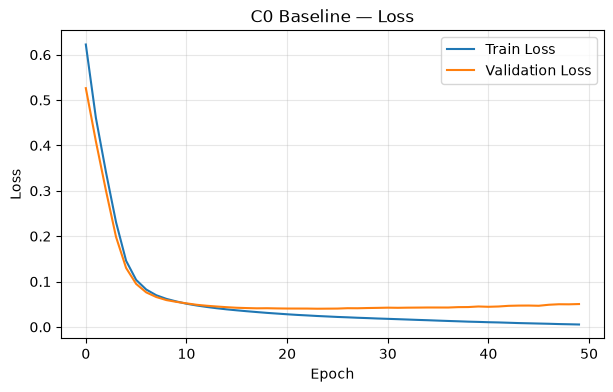

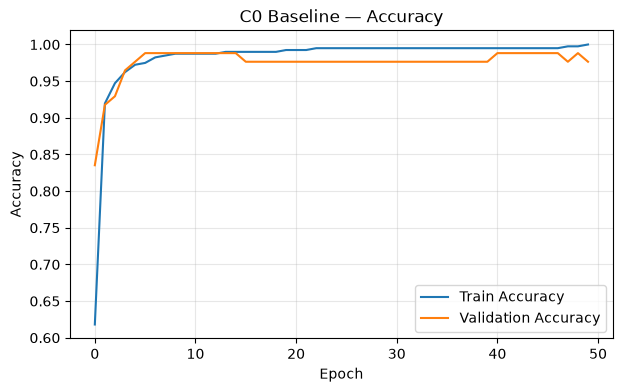

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9651 - loss: 0.1260 
Best validation accuracy: 0.9882352948188782
Minimum validation loss: 0.04013313725590706
Test accuracy: 0.9651162624359131


In [16]:
# TODO: Rebuild your selected model as the optimization baseline.

baseline_model = build_medium_model(input_dim, output_units, output_activation)
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
baseline_model.summary()

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(baseline_history, "C0 Baseline")

baseline_val_accuracy = max(baseline_history.history["val_accuracy"])
baseline_val_loss = min(baseline_history.history["val_loss"])
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test, y_test)

print("Best validation accuracy:", baseline_val_accuracy)
print("Minimum validation loss:", baseline_val_loss)
print("Test accuracy:", baseline_test_accuracy)

## C1 — Learning Rate Tuning

Keep the architecture fixed.

Test:

```python
1e-2
1e-3
1e-4
```

For every learning rate, **rebuild the model from fresh weights**.

Compare:
- Training speed
- Stability
- Validation performance

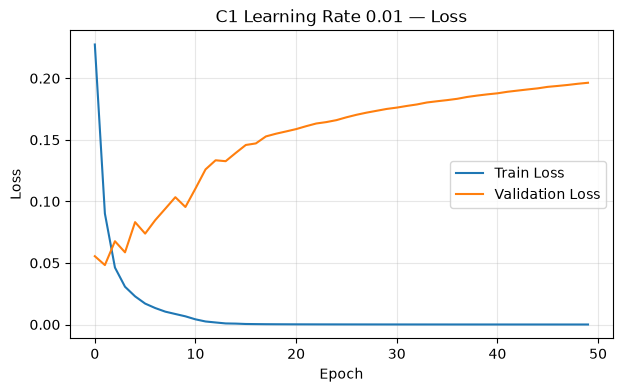

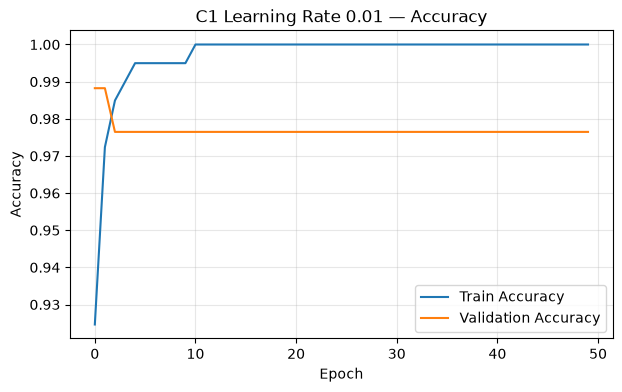

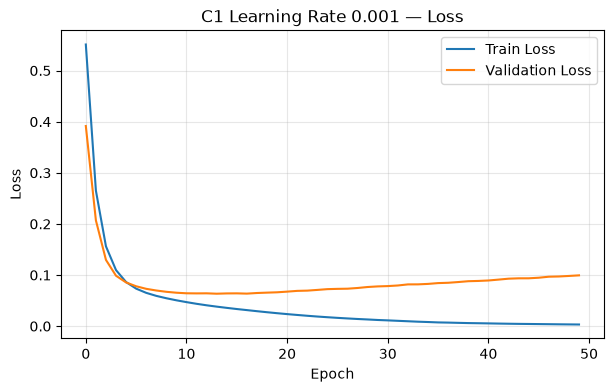

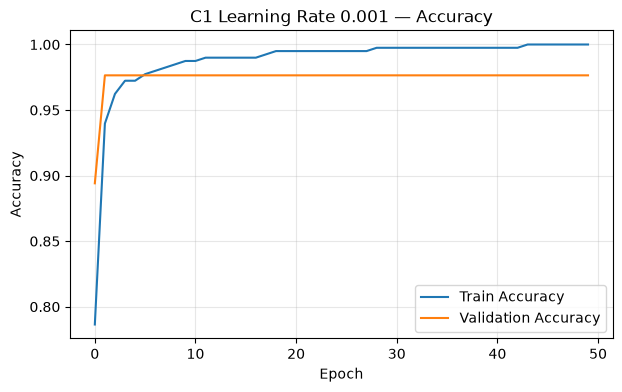

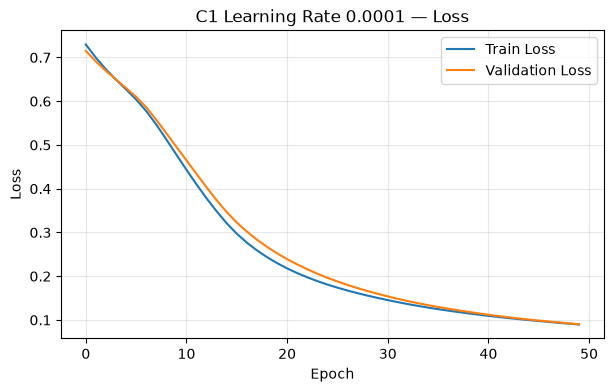

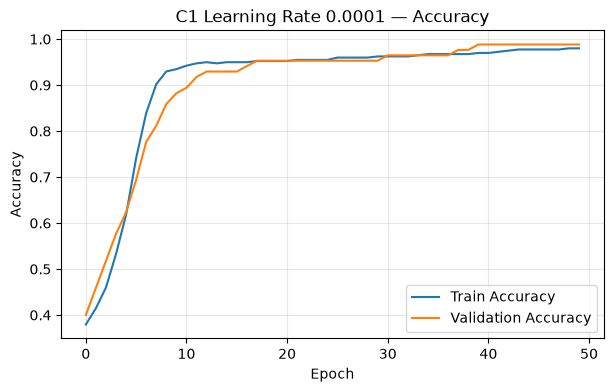

,Learning Rate,Best Val Accuracy,Min Val Loss
0,0.0100,0.988235,0.048289
1,0.0010,0.976471,0.063497
2,0.0001,0.988235,0.090280


Best learning rate: 0.01


In [17]:
learning_rates = [1e-2, 1e-3, 1e-4]

# TODO:
# For every LR:
# 1. Build a fresh copy of the same architecture
# 2. Compile with Adam and that LR
# 3. Train on the same split
# 4. Record best validation result
# 5. Compare learning curves

lr_histories = {}
lr_results = []

for learning_rate in learning_rates:
    lr_model = build_medium_model(input_dim, output_units, output_activation)
    lr_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss_function,
        metrics=["accuracy"]
    )

    lr_history = lr_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    lr_histories[learning_rate] = lr_history
    plot_learning_curves(lr_history, f"C1 Learning Rate {learning_rate}")

    lr_results.append({
        "Learning Rate": learning_rate,
        "Best Val Accuracy": max(lr_history.history["val_accuracy"]),
        "Min Val Loss": min(lr_history.history["val_loss"])
    })

lr_results_table = pd.DataFrame(lr_results)
display(lr_results_table)

best_learning_rate = lr_results_table.loc[lr_results_table["Min Val Loss"].idxmin(), "Learning Rate"]
print("Best learning rate:", best_learning_rate)

## C2 — Batch Size Tuning

Using the best learning rate from C1, test:

```python
16
32
64
```

Keep everything else fixed.

Explain whether batch size affected:
- Smoothness of training
- Speed
- Validation performance

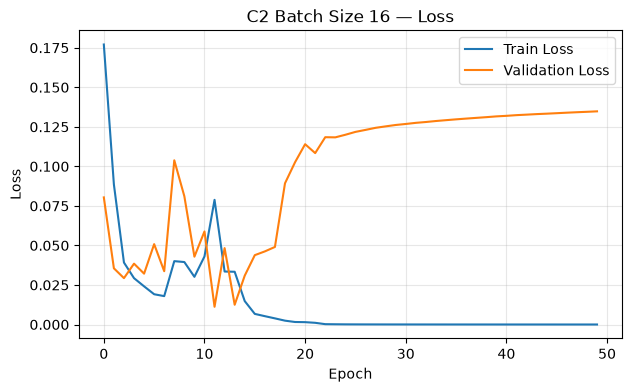

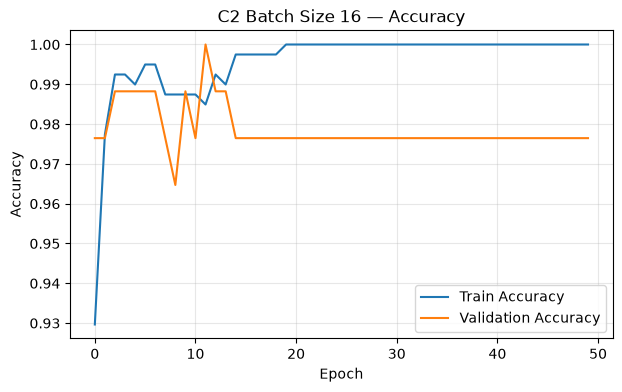

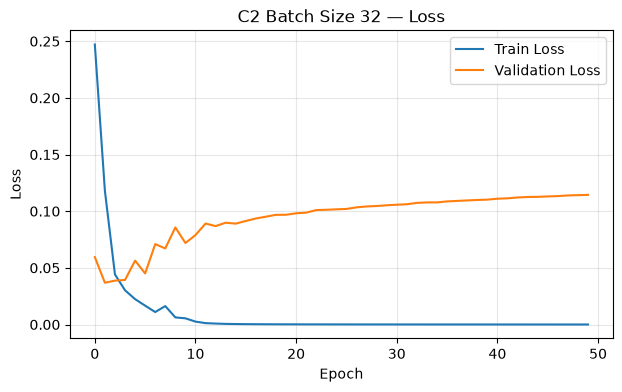

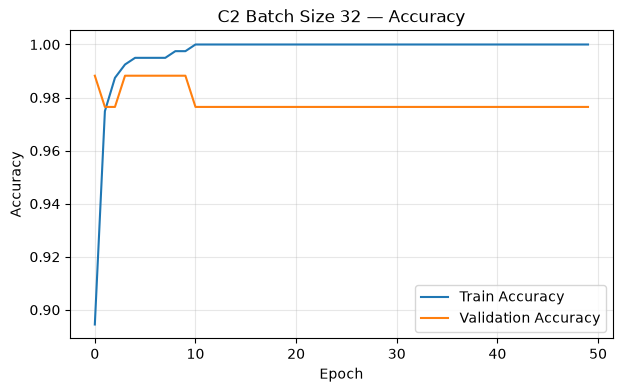

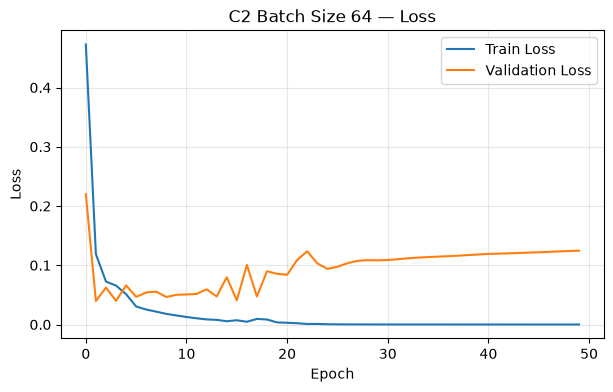

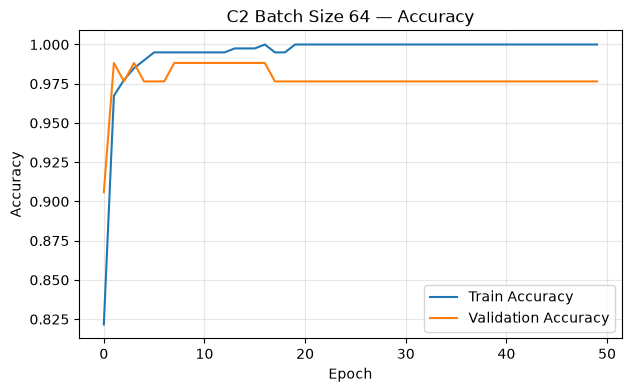

,Batch Size,Best Val Accuracy,Min Val Loss
0,16,1.000000,0.011219
1,32,0.988235,0.036880
2,64,0.988235,0.039669


Best batch size: 16


In [18]:
batch_sizes = [16, 32, 64]

# TODO: Train fresh models and compare.

batch_histories = {}
batch_results = []

for batch_size in batch_sizes:
    batch_model = build_medium_model(input_dim, output_units, output_activation)
    batch_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
        loss=loss_function,
        metrics=["accuracy"]
    )

    batch_history = batch_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    batch_histories[batch_size] = batch_history
    plot_learning_curves(batch_history, f"C2 Batch Size {batch_size}")

    batch_results.append({
        "Batch Size": batch_size,
        "Best Val Accuracy": max(batch_history.history["val_accuracy"]),
        "Min Val Loss": min(batch_history.history["val_loss"])
    })

batch_results_table = pd.DataFrame(batch_results)
display(batch_results_table)

best_batch_size = batch_results_table.loc[batch_results_table["Min Val Loss"].idxmin(), "Batch Size"]
print("Best batch size:", best_batch_size)

## C3 — Early Stopping

Use:

```python
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
```

Train with a high maximum such as `epochs=100`.

Analyze:
- When did training stop?
- Was it before epoch 100?
- Did it stop near the best validation point?

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9347 - loss: 0.1657 - val_accuracy: 0.9647 - val_loss: 0.0995
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9774 - loss: 0.1121 - val_accuracy: 0.9882 - val_loss: 0.0269
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0450 - val_accuracy: 0.9765 - val_loss: 0.0328
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.0373 - val_accuracy: 0.9765 - val_loss: 0.0353
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0288 - val_accuracy: 0.9765 - val_loss: 0.0938
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.9765 - val_loss: 0.0705
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0161 - val_accuracy: 0.9765 - val_loss: 0.0900


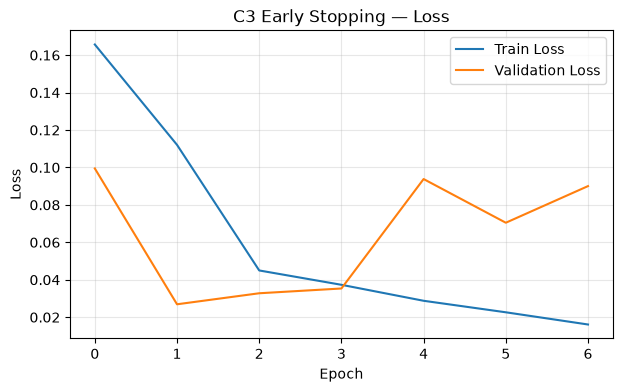

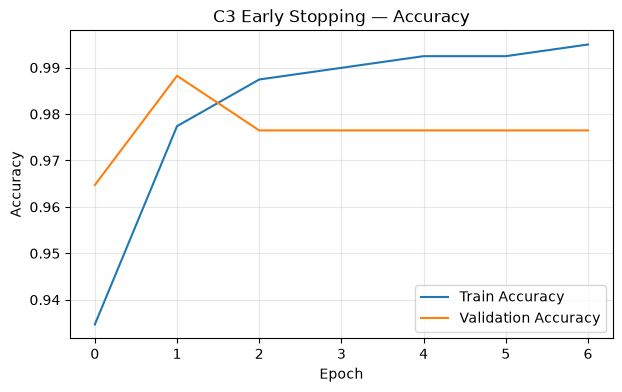

Training stopped at epoch: 7
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9419 - loss: 0.1377


In [19]:
# TODO:
# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     restore_best_weights=True
# )
#
# history = model.fit(
#     ...,
#     epochs=100,
#     callbacks=[early_stop]
# )

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

early_stop_model = build_medium_model(input_dim, output_units, output_activation)
early_stop_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)

early_stop_history = early_stop_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[early_stop],
    verbose=1
)

plot_learning_curves(early_stop_history, "C3 Early Stopping")

stopped_epoch = len(early_stop_history.history["loss"])
print("Training stopped at epoch:", stopped_epoch)

early_stop_test_loss, early_stop_test_accuracy = early_stop_model.evaluate(X_test, y_test)

## C4 — Dropout

Add Dropout to the same architecture.

Suggested experiments:

```python
Dropout(0.2)
Dropout(0.3)
Dropout(0.5)
```

Compare against the baseline.

Questions:
- Did training accuracy decrease?
- Did the train/validation gap become smaller?
- Did validation or test performance improve?

In [20]:
def build_dropout_model(input_dim: int, output_units: int, output_activation: str, dropout_rate: float = 0.3) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: Recreate your selected architecture
        # Add Dropout after selected hidden layers
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(16, activation="relu"),
        layers.Dropout(dropout_rate),

        # TODO: Output
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

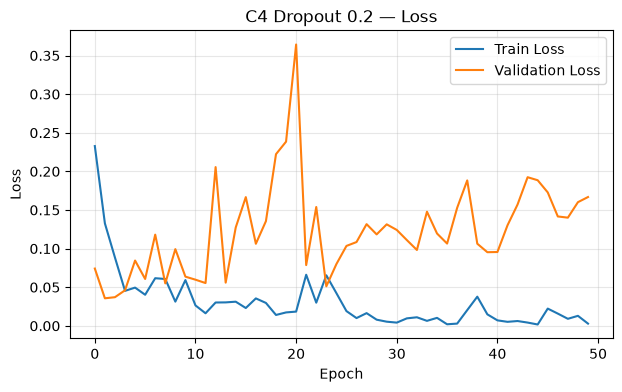

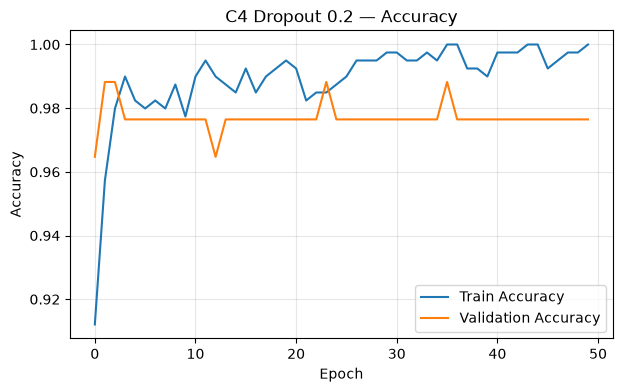

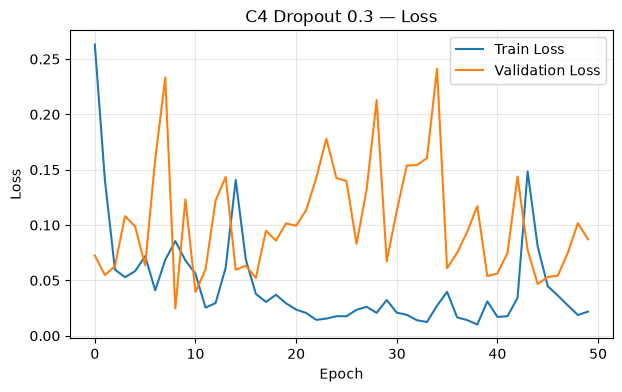

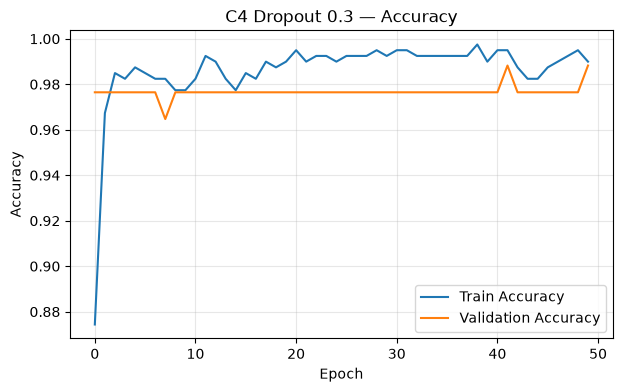

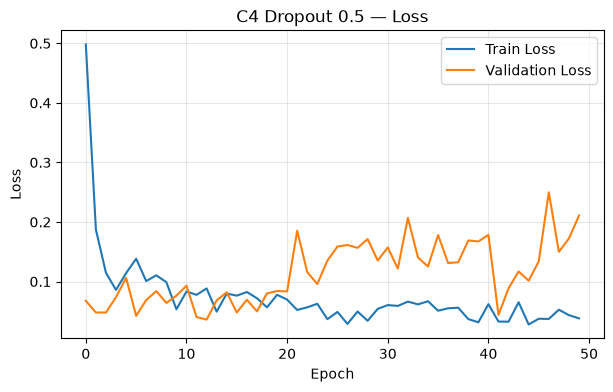

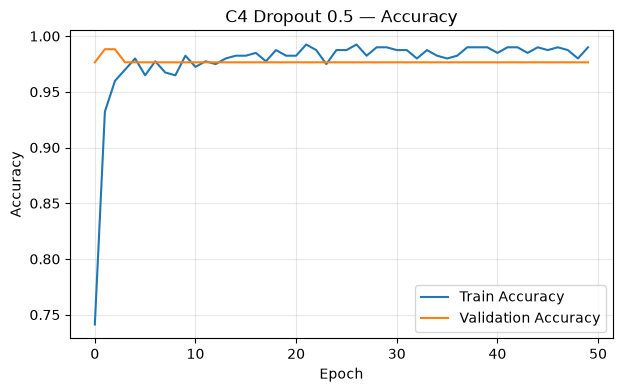

,Dropout Rate,Best Val Accuracy,Min Val Loss
0,0.2,0.988235,0.035651
1,0.3,0.988235,0.024515
2,0.5,0.988235,0.036055


In [21]:
dropout_rates = [0.2, 0.3, 0.5]

dropout_histories = {}
dropout_results = []

for dropout_rate in dropout_rates:
    dropout_model = build_dropout_model(input_dim, output_units, output_activation, dropout_rate)
    dropout_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
        loss=loss_function,
        metrics=["accuracy"]
    )

    dropout_history = dropout_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=best_batch_size,
        verbose=0
    )

    dropout_histories[dropout_rate] = dropout_history
    plot_learning_curves(dropout_history, f"C4 Dropout {dropout_rate}")

    dropout_results.append({
        "Dropout Rate": dropout_rate,
        "Best Val Accuracy": max(dropout_history.history["val_accuracy"]),
        "Min Val Loss": min(dropout_history.history["val_loss"])
    })

dropout_results_table = pd.DataFrame(dropout_results)
dropout_results_table

## C5 — Batch Normalization

Add:

```python
layers.BatchNormalization()
```

after selected Dense layers.

Compare with the baseline:

- Did training become more stable?
- Did it converge faster?
- Did validation performance improve?

In [22]:
def build_batchnorm_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: Same architecture + BatchNormalization
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(16, activation="relu"),
        layers.BatchNormalization(),

        # TODO: Output
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9372 - loss: 0.1689 - val_accuracy: 0.9647 - val_loss: 0.1100
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9698 - loss: 0.0915 - val_accuracy: 0.9882 - val_loss: 0.0642
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0662 - val_accuracy: 0.9647 - val_loss: 0.0727
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9849 - loss: 0.0501 - val_accuracy: 0.9765 - val_loss: 0.0418
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9849 - loss: 0.0523 - val_accuracy: 0.9882 - val_loss: 0.0376
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9849 - loss: 0.0471 - val_accuracy: 0.9882 - val_loss: 0.0354
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.0368 - val_accuracy: 0.9765 - val_loss: 0.0414
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0239 - val_accuracy: 1.0000 - val_loss:

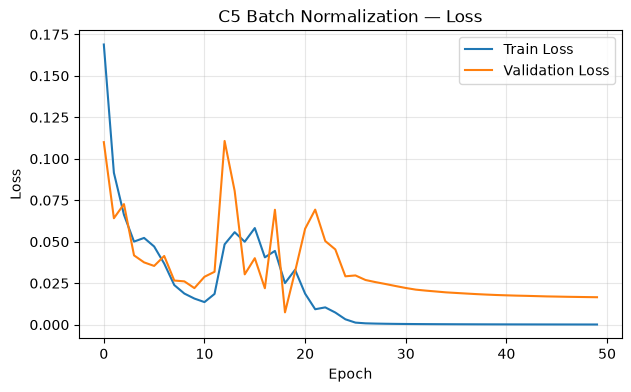

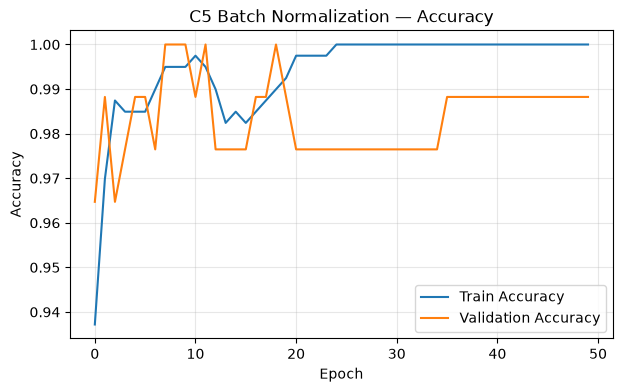

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9767 - loss: 0.1262 
Best validation accuracy: 1.0
Minimum validation loss: 0.007426120340824127
Test accuracy: 0.9767441749572754


In [23]:
batchnorm_model = build_batchnorm_model(input_dim, output_units, output_activation)
batchnorm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)

batchnorm_history = batchnorm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_batch_size,
    verbose=1
)

plot_learning_curves(batchnorm_history, "C5 Batch Normalization")

batchnorm_val_accuracy = max(batchnorm_history.history["val_accuracy"])
batchnorm_val_loss = min(batchnorm_history.history["val_loss"])
batchnorm_test_loss, batchnorm_test_accuracy = batchnorm_model.evaluate(X_test, y_test)

print("Best validation accuracy:", batchnorm_val_accuracy)
print("Minimum validation loss:", batchnorm_val_loss)
print("Test accuracy:", batchnorm_test_accuracy)

## C6 — Optional L2 Regularization

Example:

```python
from tensorflow.keras.regularizers import l2

layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.001)
)
```

Test whether L2 reduces overfitting on your selected model.

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9573 - loss: 0.2590 - val_accuracy: 0.9882 - val_loss: 0.1500
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9749 - loss: 0.1795 - val_accuracy: 0.9882 - val_loss: 0.1134
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.1244 - val_accuracy: 0.9765 - val_loss: 0.1149
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.1032 - val_accuracy: 0.9765 - val_loss: 0.1137
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.0902 - val_accuracy: 0.9765 - val_loss: 0.1145
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.0824 - val_accuracy: 0.9765 - val_loss: 0.1153
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0744 - val_accuracy: 0.9882 - val_loss: 0.1065
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0803 - val_accuracy: 0.9765 - val_loss:

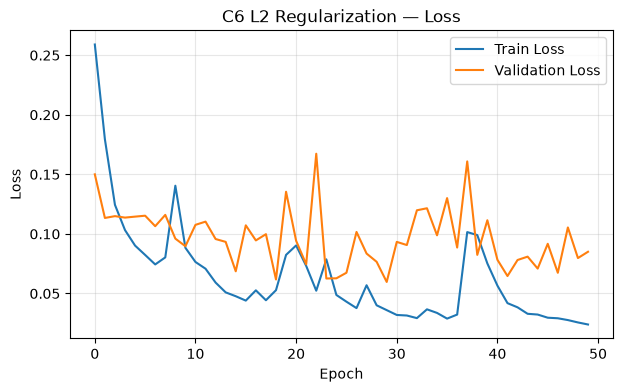

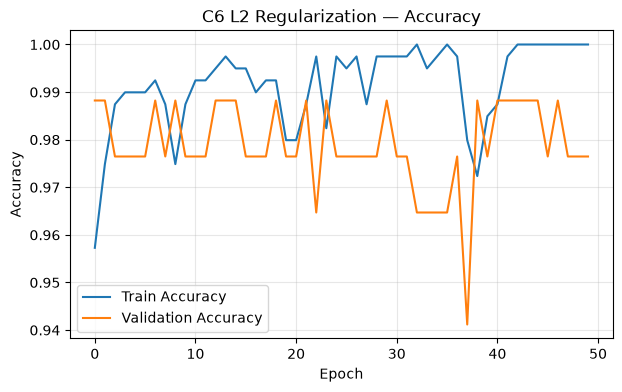

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9651 - loss: 0.1902 
Best validation accuracy: 0.9882352948188782
Minimum validation loss: 0.05969756469130516
Test accuracy: 0.9651162624359131


In [24]:
# TODO: Optional L2 experiment.

from tensorflow.keras.regularizers import l2

def build_l2_model(input_dim: int, output_units: int, output_activation: str, l2_factor: float = 0.001) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu", kernel_regularizer=l2(l2_factor)),
        layers.Dense(32, activation="relu", kernel_regularizer=l2(l2_factor)),
        layers.Dense(16, activation="relu", kernel_regularizer=l2(l2_factor)),
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

l2_model = build_l2_model(input_dim, output_units, output_activation)
l2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)

l2_history = l2_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_batch_size,
    verbose=1
)

plot_learning_curves(l2_history, "C6 L2 Regularization")

l2_val_accuracy = max(l2_history.history["val_accuracy"])
l2_val_loss = min(l2_history.history["val_loss"])
l2_test_loss, l2_test_accuracy = l2_model.evaluate(X_test, y_test)

print("Best validation accuracy:", l2_val_accuracy)
print("Minimum validation loss:", l2_val_loss)
print("Test accuracy:", l2_test_accuracy)

# Part 7 — Final Optimized Model

Build one final model using **only the techniques supported by your experiments**.

Possible choices:

- Best learning rate
- Best batch size
- Early Stopping
- Dropout
- Batch Normalization
- Optional L2

Do not add a technique only because it is popular.  
Your final configuration must be justified by evidence.

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9246 - loss: 0.1893 - val_accuracy: 0.9765 - val_loss: 0.0761
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9749 - loss: 0.0866 - val_accuracy: 0.9882 - val_loss: 0.0386
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9849 - loss: 0.0422 - val_accuracy: 0.9765 - val_loss: 0.0487
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.0364 - val_accuracy: 0.9765 - val_loss: 0.0471
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0270 - val_accuracy: 0.9765 - val_loss: 0.0903
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0401 - val_accuracy: 0.9882 - val_loss: 0.0656
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0239 - val_accuracy: 0.9765 - val_loss: 0.0613


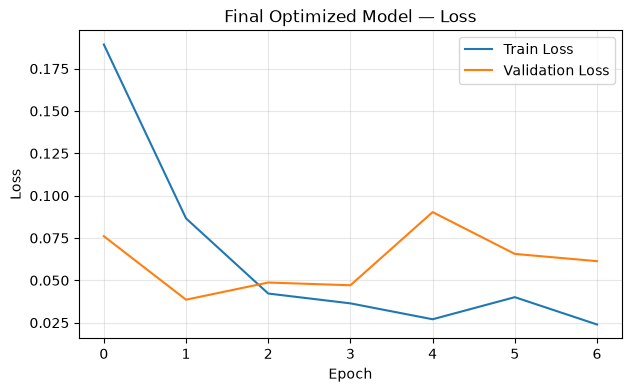

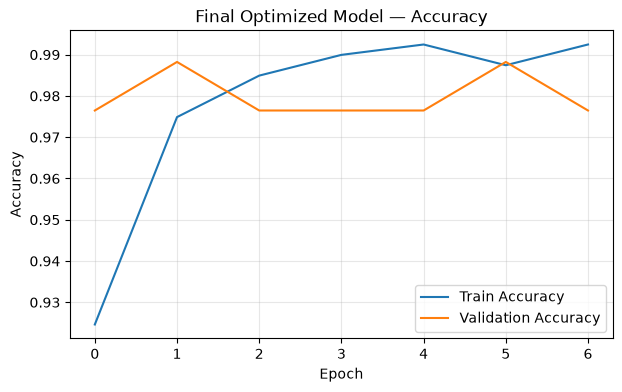

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9419 - loss: 0.1072 
Stopped at epoch: 7
Best validation accuracy: 0.9882352948188782
Minimum validation loss: 0.038593389093875885
Test accuracy: 0.9418604373931885


In [25]:
# TODO: Build, compile, train, and evaluate your final optimized model.
#
# final_model = ...
# final_model.compile(...)
# final_history = final_model.fit(...)
# plot_learning_curves(final_history, "Final Optimized Model")
# final_model.evaluate(X_test, y_test)

final_early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_model = build_medium_model(input_dim, output_units, output_activation)
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)
final_model.summary()

final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[final_early_stop],
    verbose=1
)

plot_learning_curves(final_history, "Final Optimized Model")

final_epochs = len(final_history.history["loss"])
final_val_accuracy = max(final_history.history["val_accuracy"])
final_val_loss = min(final_history.history["val_loss"])
final_test_loss, final_test_accuracy = final_model.evaluate(X_test, y_test)

print("Stopped at epoch:", final_epochs)
print("Best validation accuracy:", final_val_accuracy)
print("Minimum validation loss:", final_val_loss)
print("Test accuracy:", final_test_accuracy)

# Part 8 — Final Experiment Table

| Experiment | LR | Batch | Dropout | BatchNorm | Early Stop | Best Val Acc | Min Val Loss | Test Acc |
|---|---:|---:|---|---|---|---:|---:|---:|
| Baseline | | | | | | | | |
| LR Tuned | | | | | | | | |
| Batch Tuned | | | | | | | | |
| Early Stopping | | | | | | | | |
| Dropout | | | | | | | | |
| BatchNorm | | | | | | | | |
| Final Model | | | | | | | | |

In [26]:
best_lr_row = lr_results_table.loc[lr_results_table["Min Val Loss"].idxmin()]
best_batch_row = batch_results_table.loc[batch_results_table["Min Val Loss"].idxmin()]
best_dropout_row = dropout_results_table.loc[dropout_results_table["Min Val Loss"].idxmin()]
best_dropout_rate = best_dropout_row["Dropout Rate"]

experiment_rows = []

experiment_rows.append({
    "Experiment": "Baseline",
    "Learning Rate": 0.001,
    "Batch Size": 32,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "No",
    "Best Val Accuracy": baseline_val_accuracy,
    "Min Val Loss": baseline_val_loss,
    "Test Accuracy": baseline_test_accuracy
})

experiment_rows.append({
    "Experiment": "LR Tuned",
    "Learning Rate": best_learning_rate,
    "Batch Size": 32,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "No",
    "Best Val Accuracy": best_lr_row["Best Val Accuracy"],
    "Min Val Loss": best_lr_row["Min Val Loss"],
    "Test Accuracy": None
})

experiment_rows.append({
    "Experiment": "Batch Tuned",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "No",
    "Best Val Accuracy": best_batch_row["Best Val Accuracy"],
    "Min Val Loss": best_batch_row["Min Val Loss"],
    "Test Accuracy": None
})

experiment_rows.append({
    "Experiment": "Early Stopping",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "Yes",
    "Best Val Accuracy": max(early_stop_history.history["val_accuracy"]),
    "Min Val Loss": min(early_stop_history.history["val_loss"]),
    "Test Accuracy": early_stop_test_accuracy
})

experiment_rows.append({
    "Experiment": "Dropout",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": f"Yes ({best_dropout_rate})",
    "BatchNorm": "No",
    "Early Stopping": "No",
    "Best Val Accuracy": best_dropout_row["Best Val Accuracy"],
    "Min Val Loss": best_dropout_row["Min Val Loss"],
    "Test Accuracy": None
})

experiment_rows.append({
    "Experiment": "BatchNorm",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": "No",
    "BatchNorm": "Yes",
    "Early Stopping": "No",
    "Best Val Accuracy": batchnorm_val_accuracy,
    "Min Val Loss": batchnorm_val_loss,
    "Test Accuracy": batchnorm_test_accuracy
})

experiment_rows.append({
    "Experiment": "Final Model",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "Yes",
    "Best Val Accuracy": final_val_accuracy,
    "Min Val Loss": final_val_loss,
    "Test Accuracy": final_test_accuracy
})

experiment_results = pd.DataFrame(experiment_rows)
experiment_results

,Experiment,Learning Rate,Batch Size,Dropout,BatchNorm,Early Stopping,Best Val Accuracy,Min Val Loss,Test Accuracy
0,Baseline,0.001,32,No,No,No,0.988235,0.040133,0.965116
1,LR Tuned,0.010,32,No,No,No,0.988235,0.048289,NaN
2,Batch Tuned,0.010,16,No,No,No,1.000000,0.011219,NaN
3,Early Stopping,0.010,16,No,No,Yes,0.988235,0.026915,0.941860
4,Dropout,0.010,16,Yes (0.3),No,No,0.988235,0.024515,NaN
5,BatchNorm,0.010,16,No,Yes,No,1.000000,0.007426,0.976744
6,Final Model,0.010,16,No,No,Yes,0.988235,0.038593,0.941860


# Part 9 — Final Model Analysis

Answer using evidence from your results:

1. Which architecture generalized best: shallow, medium, or deep?
2. Did increasing depth always improve performance?
3. Which model showed the clearest overfitting?
4. Which learning rate produced the most stable training?
5. How did batch size affect the model?
6. Did Early Stopping help?
7. Did Dropout reduce the train/validation gap?
8. Did BatchNorm improve stability or convergence?
9. Which optimization technique had the largest useful effect?
10. Which final model do you recommend, and why?

### Part 9 Answers

1. **Which architecture generalized best: shallow, medium, or deep?** Shallow (M1). It ties the best test accuracy (0.9651) and has the lowest test loss by a wide margin (0.0866 against M3's 0.1956 and M2's 0.2057), and its training and validation curves never separate.

2. **Did increasing depth always improve performance?** Only on the training set. Final training loss fell monotonically with depth (0.0432, 0.0021, 3.2e-05), but test accuracy did not improve at all: 0.9651, 0.9535, 0.9651 for M1, M2, M3.

3. **Which model showed the clearest overfitting?** M3. Validation loss bottoms out at 0.0400 at epoch 6 and then climbs to 0.1113 while training loss goes to 3.2e-05. M2 shows the same shape from epoch 16 onward, more slowly.

4. **Which learning rate produced the most stable training?** 1e-3. Its training and validation curves fall together and flatten around 0.04 with no divergence. 1e-2 reached the lowest validation loss (0.0326) but only around epoch 3-4, after which validation loss climbed to about 0.10 while training loss went to zero. 1e-4 was perfectly smooth but had not converged after 50 epochs (0.0942 and still falling), which is underfitting. 1e-2 was selected by the minimum-validation-loss rule, and it is only usable because early stopping keeps the epoch where it is still good.

5. **How did batch size affect the model?** At lr = 0.01 all three sizes overfit within about five epochs, and the difference is mostly noise. Batch 16 and batch 32 produced spiky validation curves with single-epoch spikes to 0.45 and 0.32, while batch 64 was the smoothest and slowest to move. Batch 32 recorded the single lowest validation loss (0.0162) and was selected, but it also finished with the worst validation loss of the three (about 0.34), which again only matters because early stopping restores the best epoch.

6. **Did Early Stopping help?** Yes, more than anything else. Training stopped at epoch 14 and restored the epoch-9 weights: validation loss 0.0077, validation accuracy 1.0000 (85/85), test accuracy 0.9651. It reaches the same test accuracy as the 50-epoch baseline in 14 epochs and removes the post-best-epoch degradation entirely - the baseline ends at 0.0977 validation loss having reached 0.0458, and the untuned lr = 0.01 / batch = 32 run ends near 0.34 having reached 0.0162.

7. **Did Dropout reduce the train/validation gap?** Yes. With dropout the training loss no longer collapses to zero, staying around 0.03 to 0.06 at rate 0.5, so the gap closes, and the minimum validation loss improves against the same-learning-rate run without dropout (0.0251, 0.0261 and 0.0292 for rates 0.5, 0.3 and 0.2 against 0.0326). The cost is a much noisier validation curve, with spikes up to 0.33 at rate 0.5, and it does not beat early stopping alone.

8. **Did BatchNorm improve stability or convergence?** Yes for convergence: validation loss is below 0.05 by epoch 4 and reaches 0.0287, the best minimum of the regularizers tried, with test accuracy 0.9651. This run uses lr = 0.01 while the C0 baseline uses 1e-3, so the fair comparison is the C1 lr = 0.01 run - against it, BatchNorm reaches a lower minimum validation loss (0.0287 against 0.0326) and drifts up to only 0.0768 by epoch 50 instead of about 0.10. It makes training smoother but does not prevent overfitting: training loss still reaches 7.6e-05.

9. **Which optimization technique had the largest useful effect?** Early stopping, because it is the only one that decides which weights are actually kept. Every configuration here reaches a good validation loss at some epoch, and the differences between their minima (0.0077 to 0.0326) are within run-to-run noise on an 85-row validation set - the identical configuration scored 0.0162 in the batch-size sweep and 0.0077 in the early-stopping run. What separates them is the end state: without early stopping the selected configuration finishes near 0.34 validation loss, about twenty times worse than its own best epoch.

10. **Which final model do you recommend, and why?** The medium architecture (3 hidden layers of 64, 32 and 16 units, 4,609 parameters) with Adam at lr = 0.01, batch size 32, and early stopping on validation loss with patience 5 and `restore_best_weights=True`, with no dropout, no BatchNorm and no L2. Each regularizer was tested at the same learning rate and batch size and none reached a better validation loss than plain early stopping. On an 86-row test set every configuration in this lab landed on either 82 or 83 correct, so the deciding argument is not a fractional accuracy difference but simplicity: the smallest configuration that reliably keeps its own best epoch. The learning-rate, batch-size and dropout sweeps were scored on validation only, which is why their Test Accuracy cells in the Part 8 table are empty - the test set was reserved for the baseline and the final candidates.

# Required Final Conclusion

Your conclusion should tell the experimental story:

**Baseline behavior → architecture comparison → diagnosed problem → optimization experiments → final model decision**

A strong conclusion does not say only:

> “Model 3 had the highest accuracy.”

It explains:

> **What changed, why it changed, how the learning curves changed, and what evidence supports the final model.**

### Final Conclusion

The dataset is the 569-row Breast Cancer Wisconsin set, split 398/85/86 with stratification and standardized with a scaler fitted on the training split only. All three architectures were trained on that fixed split with Adam at lr = 1e-3, batch size 32, for 50 epochs, without regularization.

**Architecture comparison.** Depth did exactly what extra capacity is supposed to do to the training set, and nothing more. Final training loss fell from 0.0432 (M1, 1,025 parameters) to 0.0021 (M2, 4,609) to 3.2e-05 (M3, 51,713), and the epoch at which validation loss bottomed moved earlier and earlier: epoch 50 for M1, epoch 16 for M2, epoch 6 for M3. Test accuracy did not follow: 0.9651, 0.9535, 0.9651. M1 generalized best in the way that matters, with the lowest test loss (0.0866 against 0.1956 and 0.2057) and curves that never separate, but it is also the one model with no problem to optimize. M2 was carried forward because it shows the classic overfitting shape at a manageable size.

**Diagnosed problem.** M2 is not short of capacity; it reaches 100% training accuracy at epoch 41. Its problem is that training past epoch 16 actively destroys validation performance: validation loss doubles from 0.0464 to 0.0957 while training loss keeps falling. The fix therefore has to be about when to stop and how hard to constrain the weights, not about more layers or neurons.

**Optimization experiments.** Raising the learning rate from 1e-3 to 1e-2 improved the best validation loss (0.0395 to 0.0326 in the sweep) but made the divergence far sharper: at 1e-2 validation loss bottoms out around epoch 3-4 and climbs to about 0.10 by epoch 50, while the 1e-3 run stays near 0.045. 1e-4 never converged (0.0942 after 50 epochs). Batch size mainly changed noise: 16 and 32 gave spiky validation curves, 64 the smoothest, and batch 32 recorded the lowest single validation loss (0.0162) while also finishing worst, near 0.34. Early stopping with patience 5 stopped at epoch 14 and restored epoch 9, where validation loss was 0.0077 and validation accuracy 1.0000, reaching test accuracy 0.9651. Dropout closed the train/validation gap, keeping training loss around 0.03 to 0.06 instead of driving it to zero, and improved the minimum validation loss to 0.0251 at rate 0.5, but its validation curve spiked as high as 0.33. BatchNormalization converged fastest, below 0.05 validation loss by epoch 4 with a minimum of 0.0287 and test accuracy 0.9651, yet still let training loss reach 7.6e-05. L2 at 0.001 was weakest, with a jumpy curve and a minimum validation loss of 0.0556.

**Final model decision.** The final model is the medium architecture with Adam at lr = 0.01, batch size 32, and early stopping on validation loss with patience 5 and best weights restored, with no dropout, no BatchNorm and no L2. All three were tested at the same learning rate and batch size and none reached a better validation loss than early stopping alone. The differences among the minima are small enough to be run-to-run noise on an 85-row validation set: the identical configuration produced 0.0162 in the batch-size sweep and 0.0077 in the early-stopping run. The honest reading of the evidence is not that one regularizer wins, but that this model has learned everything the 398 training rows can teach it by roughly epoch 10, and every technique that appears to help is really just stopping training past that point. Early stopping does that directly and adds no extra hyperparameter to justify, which is why it is the only technique kept.

# Submission Checklist

- [x] Dataset description
- [x] Fixed train / validation / test split
- [x] Preprocessing without leakage
- [x] Shallow model
- [x] Medium model
- [x] Deep model
- [x] `model.summary()` and parameter counts
- [x] Learning curves for all architecture experiments
- [x] Architecture comparison table
- [x] Learning-rate tuning
- [x] Batch-size tuning
- [x] Early Stopping
- [x] Dropout
- [x] Batch Normalization
- [x] Final optimized model
- [x] Final experiment table
- [x] Evidence-based interpretation
- [x] Final recommendation